In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tqdm.auto as tqdm
from collections import namedtuple
from scipy.optimize import curve_fit
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator

In [2]:
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

In [3]:
def valid_smiles(smi):
    if smi is None or "." in smi:
        return False
    try:
        mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
        return mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi)) is not None
    except:
        return False

In [4]:
smiles = pd.read_csv("../data/raw/nsc_smiles.csv")
smiles = smiles[
    ~smiles["NSC"].isna() & ~smiles["SMILES"].isna()
]  # remove ill-formed entries: missing SMILES or NSC ident
valid = [valid_smiles(smi) for smi in tqdm.tqdm(smiles["SMILES"])]
smiles = smiles[valid]
smiles = smiles.astype({"NSC": int})
smiles

  0%|          | 0/319480 [00:00<?, ?it/s]

,NSC,SMILES
0,1,CC1=CC(=O)C=CC1=O
1,2,S(Sc1nc2ccccc2s1)c3nc4ccccc4s3
2,3,Oc1c(Cl)cc(cc1[N+](=O)[O-])[N+](=O)[O-]
3,4,Nc1ncc(s1)[N+](=O)[O-]
4,5,Nc1ccc2C(=O)c3ccccc3C(=O)c2c1
...,...,...
325420,854987,O=C1N=C(NCc2cccs2)S/C/1=C\c3ccc4ncccc4c3
325421,854988,CN(C)Cc1ccc(c(C)c1)c2cnc(NCc3c(F)ccc4OCCc34)n5...
325422,855177,COc1nc(C)cc(O[C@@H]2CC[C@H](N)C2)c1c3cc(Nc4cnc...
325424,855361,CCN1C(=NN(C1=O)c2cc3C(=CN(C(=O)c3cc2F)c4ccccc4...


In [5]:
nci = pd.read_csv("../data/raw/DOSERESP.csv")

In [6]:
print(len(nci))
nci = nci.merge(smiles, on="NSC", how="inner")
print(len(nci))

23978099
23164693


In [9]:
def sigmoid(x, h, slope):
    return 1 / (1 + np.exp((x - h) / slope))


def ic50_table(d):
    tbl_keys = ["EXPID", "CELL_NAME", "NSC", "SMILES"]
    IC50 = namedtuple("IC50", tbl_keys + ["IC50"])

    ic50_results = []

    for (expid, cell_name, nsc, smiles), g in tqdm.tqdm(d.groupby(tbl_keys)):
        inh_ptc = g["AVERAGE_PTC"]
        conc = g["CONCENTRATION"]

        if not (inh_ptc.min() < 50 and inh_ptc.max() > 50):
            continue

        try:
            conc = g["CONCENTRATION"].values
            inh = g["AVERAGE_PTC"].values / 100
            ps, _ = curve_fit(
                sigmoid,
                conc,
                inh,
                p0=[np.median(conc), 1],
                bounds=([conc.min(), 0.01], [conc.max(), 100]),
            )
            ic50_results.append(IC50(expid, cell_name, nsc, smiles, ps[0]))
        except RuntimeError:
            continue  # Skip if curve fitting fails

    return pd.DataFrame(ic50_results)

  0%|          | 0/81271 [00:00<?, ?it/s]

/tmp/ipykernel_6498/2434570916.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  ps, _ = curve_fit(


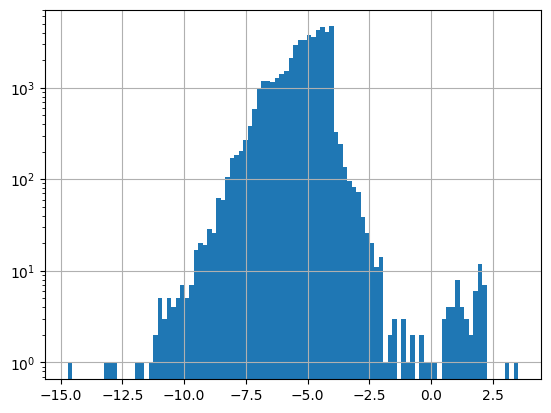

In [10]:
target = "A549/ATCC"
d = nci[nci["CELL_NAME"] == target]
ic50_df = ic50_table(d)
ic50_df["IC50"].hist(bins=100)
ic50_df.to_csv("../data/raw/atcc.csv")
plt.yscale("log")

  0%|          | 0/80978 [00:00<?, ?it/s]

/tmp/ipykernel_6498/2434570916.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  ps, _ = curve_fit(


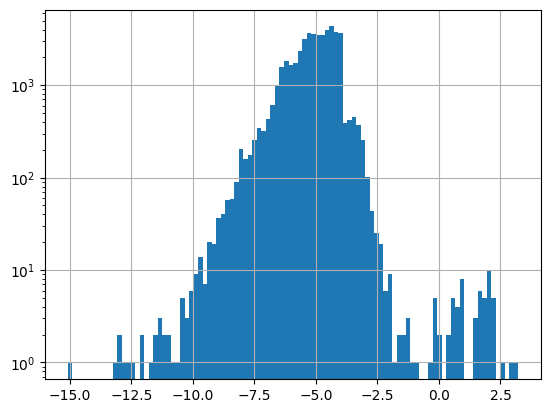

In [11]:
target = "OVCAR-8"
d = nci[nci["CELL_NAME"] == target]
ic50_df = ic50_table(d)
ic50_df["IC50"].hist(bins=100)
ic50_df.to_csv("../data/raw/ovcar.csv")
plt.yscale("log")